# Bayesian Modeling to characterize the reliability of SC

In [43]:
import h5py
import numpy as np
import pymc as pm
import seaborn as sns
import matplotlib.pyplot as plt

from simulate_sc import (
    simulate_sc_no_bias,
    simulate_sc_noisy_copies,
    simulate_sc_length_bias,
    simulate_sc_density_bias,
    simulate_sc_fns,
    simulate_sc_fps,
)

atlas_path = "/data/probconnatlas/wm.connatlas.scale1.h5"
# Load consistency matrix
with h5py.File(atlas_path, "r") as f:
        print(f.keys())
        print(f["matrices"].keys())
        print(f["matrices"]["consistency"])
        consistency_matrix = np.array(f["matrices"]["consistency"])
        print("Loaded consistency matrix")
        print(consistency_matrix)

# Load simulated SC
SC_matrices, noise = simulate_sc_density_bias(atlas_path=atlas_path, connectome_atlas_as_ref=False, num_sessions=36, atlas_dim=5)
#SC_matrices, noise = simulate_sc_density_bias(atlas_path=atlas_path)
num_sessions = SC_matrices.shape[0]
atlas_dim = SC_matrices.shape[1]

<KeysViewHDF5 ['atlas', 'header', 'matrices']>
<KeysViewHDF5 ['consistency', 'length', 'numbStlines']>
<HDF5 dataset "consistency": shape (95, 95), type "<u2">
Loaded consistency matrix
[[66 65 65 ...  0  1 66]
 [65 65 65 ...  0  0 60]
 [65 65 60 ...  0  0 15]
 ...
 [ 0  0  0 ... 17 64 57]
 [ 1  0  0 ... 64 66 66]
 [66 60 15 ... 57 66 66]]
Simulating a reference SC matrix using a log-normal distribution.
Simulated a series of 36 SC matrices of shape (5x5) with higher variability (std=100) in lower density connections.


We can determine if a connection exists or not based on the consistency matrix from Yasser's atlas. To binarize the consistency matrix, we have to choose a threshold.

Threshold to binarize consistency matrix: 15.0


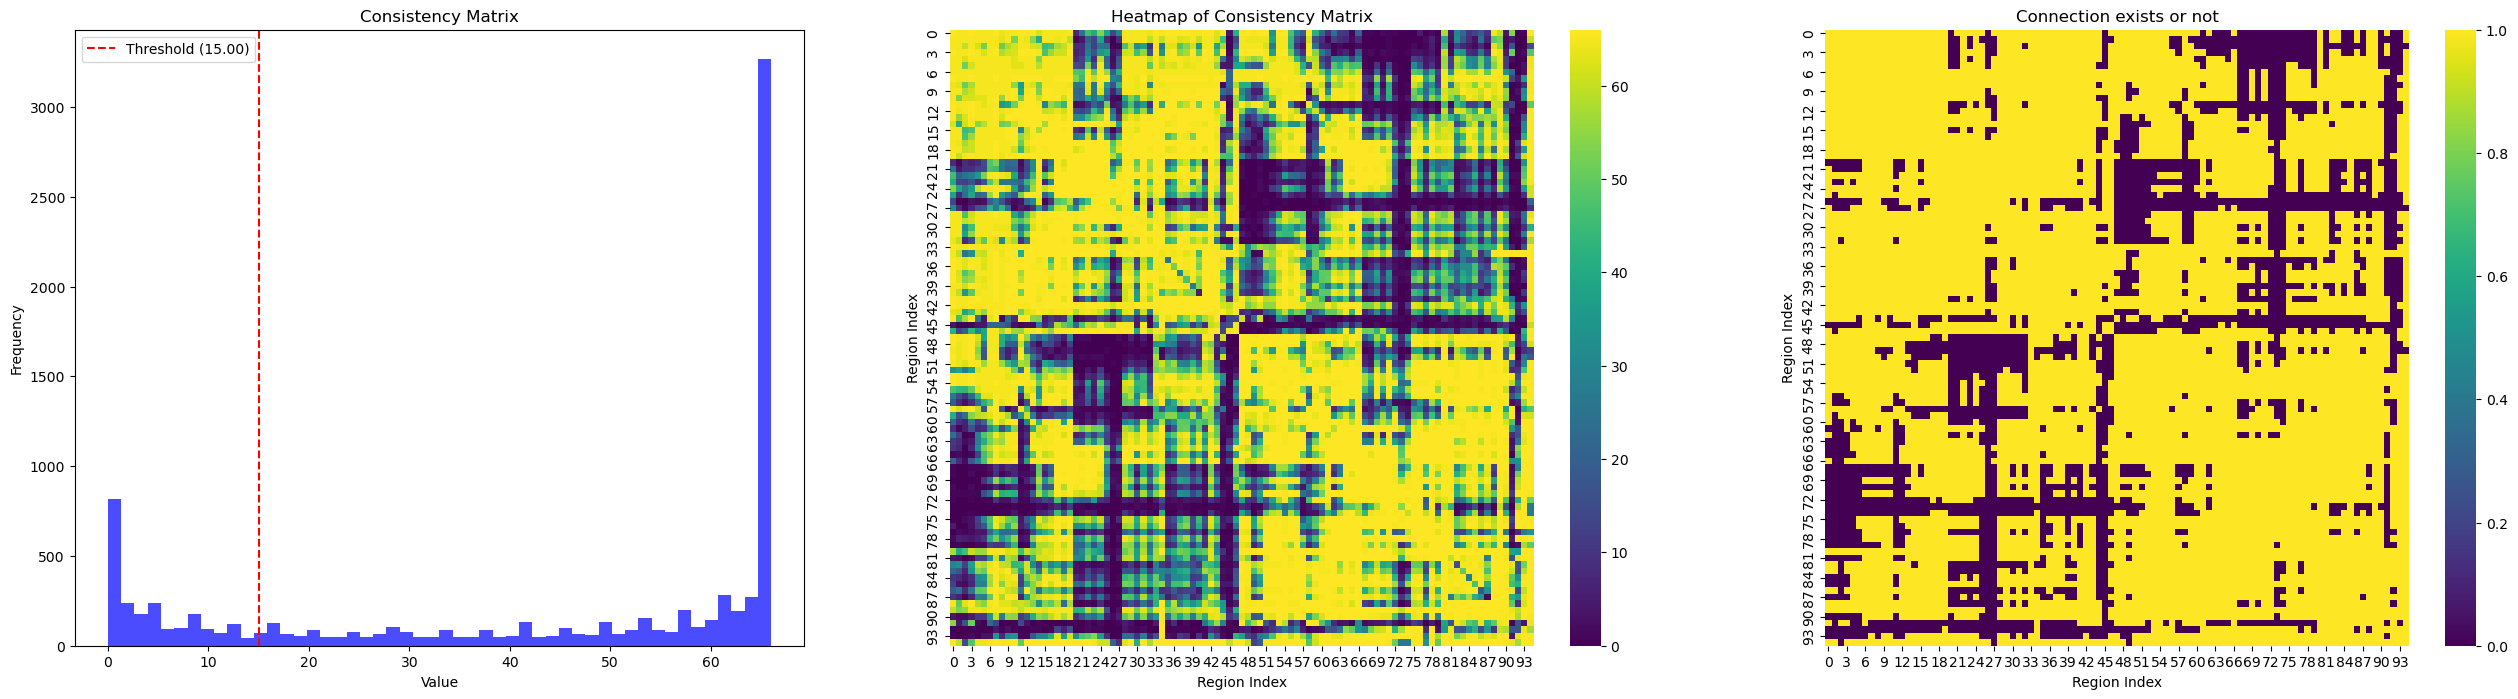

In [44]:
threshold = np.percentile(consistency_matrix[consistency_matrix>0], 20)
print("Threshold to binarize consistency matrix:", threshold)

# Plot histogram for consistency_matrix
plt.figure(figsize=(32, 8))
plt.subplot(1, 3, 1)
plt.hist(consistency_matrix.flatten(), bins=50, color='blue', alpha=0.7)
plt.axvline(x=threshold, color='red', linestyle='--', label=f'Threshold ({threshold:.2f})')
plt.legend()
plt.title('Consistency Matrix')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.heatmap(consistency_matrix, cmap='viridis', cbar=True)
plt.title('Heatmap of Consistency Matrix')
plt.xlabel('Region Index')
plt.ylabel('Region Index')

plt.subplot(1, 3, 3)
sns.heatmap(consistency_matrix > threshold, cmap='viridis', cbar=True)
plt.title('Connection exists or not')
plt.xlabel('Region Index')
plt.ylabel('Region Index')
plt.show()

In [45]:
# Compute the percentage of zero connections
zero_connections_percentage = np.sum(consistency_matrix < threshold) / consistency_matrix.size * 100
print(f"Percentage of zero connections: {zero_connections_percentage:.2f}%")

Percentage of zero connections: 23.96%


## Model on data simulated by fixing the bayesian parameters

Thinking about the problem, I converged to the following model of the density distribution:

p(D) = p(D| c=0)p(c=0) + p(D| c=1)p(c=1)

     = pi_0 * Exp(lambda) + (1-pi_0) * TruncatedNormal(mu, sigma)

with 

pi_0 ~ Beta(1,1)

lambda ~ Gamma(2,3)

sigma ~ HalfNormal(0,0.1)

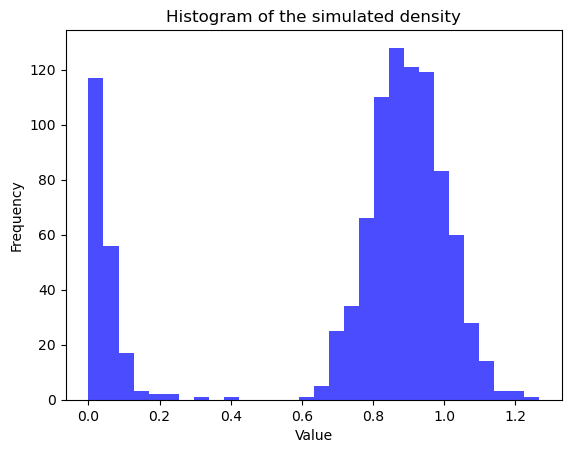

In [46]:
import pymc as pm
import numpy as np
import arviz as az

# Dummy data
true_pi0 = 0.2
true_sigma = 0.1
true_mu = 0.9
true_lambda = 0.05

n_samples = 1000
# Randomly assign whether the connection is present or not
z_true = np.random.binomial(1, 1 - true_pi0, size=n_samples)
# Draw from an exponential distribution where the connection is absent and from a normal distribution where the connection is present
density_obs = np.where(z_true == 0, np.random.exponential(true_lambda, size=n_samples), np.random.normal(true_mu, true_sigma, size=n_samples))
# Cast negative values to zero
density_obs = np.clip(density_obs, 0, None)

plt.hist(density_obs, bins=30, color='blue', alpha=0.7)
plt.title('Histogram of the simulated density')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

### Prior predictive sampling 
To see if our model make sense, we can conduct prior predictive sampling to generate simulated data from the model. Then, we compare these simulations to the actual data and verify the distribution are more or less similar. If they are not, it is likely your model is not well designed.

/home/cprovins/miniconda3/envs/pymc_env/lib/python3.12/site-packages/pymc/distributions/mixture.py:453: MixtureTransformWarning: No safe default transform found for Mixture distribution density. This can happen when components have different supports or default transforms.
If appropriate, you can specify a custom transform for more efficient sampling.
  transform_warning()
Sampling: [density, lambda_exp, pi0, sigma]


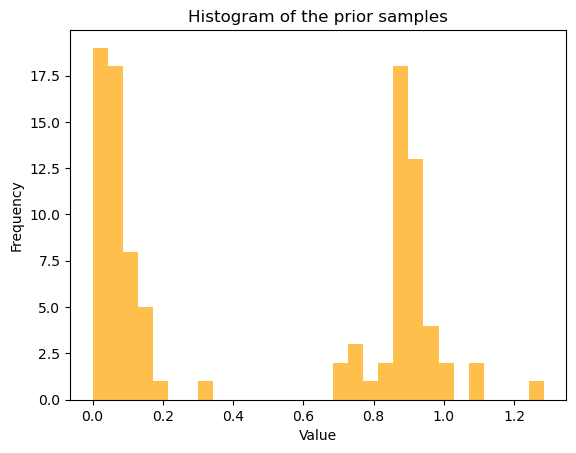

In [47]:
with pm.Model() as prior_model:

    # Prior for sparsity
    pi0 = pm.Beta('pi0', alpha=1, beta=1)

    # Prior for sigma (spread of real connections)
    sigma = pm.HalfNormal('sigma', sigma=0.1)

    # Fixed mean for real connections
    #mu = pm.Normal('mu', mu=true_mu, sigma=0.5)
    mu = true_mu

    # Prior for lambda (rate of Exponential for small spurious connections)
    lambda_exp = pm.Gamma('lambda_exp', alpha=15, beta=1) 

    # Component 1: Exponential distribution for "no connection"
    density_small = pm.Exponential.dist(lam=lambda_exp)

    # Component 2: Truncated Normal distribution for "existing connection"
    density_existing = pm.TruncatedNormal.dist(mu=mu, sigma=sigma, lower=0)

    # Mixture of the twos
    density = pm.Mixture(
        'density',
        w=[pi0, 1 - pi0],
        comp_dists=[density_small, density_existing]
    )

    prior_samples = pm.sample_prior_predictive(100)

plt.hist(prior_samples.prior["density"].values.flatten(), bins=30, color='orange', alpha=0.7)
plt.title('Histogram of the prior samples')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [48]:
with pm.Model() as model:

    # Prior for sparsity
    pi0 = pm.Beta('pi0', alpha=1, beta=1)

    # Prior for sigma (spread of real connections)
    sigma = pm.HalfNormal('sigma', sigma=0.1)

    # Fixed mean for real connections
    #mu = pm.Normal('mu', mu=true_mu, sigma=0.5)
    mu = true_mu

    # Prior for lambda (rate of Exponential for small spurious connections)
    #lambda_exp = pm.Gamma('lambda_exp', alpha=1, beta=1) 
    lambda_exp = pm.HalfNormal('lambda_exp', sigma=0.1)

    # Component 1: Exponential distribution for "no connection"
    density_small = pm.Exponential.dist(lam=lambda_exp)

    # Component 2: Truncated Normal distribution for "existing connection"
    density_existing = pm.TruncatedNormal.dist(mu=mu, sigma=sigma, lower=0)

    # Mixture of the twos
    density = pm.Mixture(
        'density',
        w=[pi0, 1 - pi0],
        comp_dists=[density_small, density_existing],
        observed=density_obs
    )

### Model fitting
Now that we checked the model prior samples distribution look similar to our observed data, let us fit the model to the data and estimate the different model parameters.

In [49]:
with model:   
    trace = pm.sample(2000, tune=1000, target_accept=0.9)

# Summarize
az.summary(trace, var_names=["pi0", "sigma", "lambda_exp"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [pi0, sigma, lambda_exp]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 5 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
pi0,0.259,0.016,0.229,0.290,0.000,0.000,9250.0,6624.0,1.0
sigma,0.093,0.003,0.088,0.098,0.000,0.000,7051.0,5780.0,1.0
lambda_exp,1.327,0.064,1.211,1.450,0.001,0.001,7729.0,5868.0,1.0


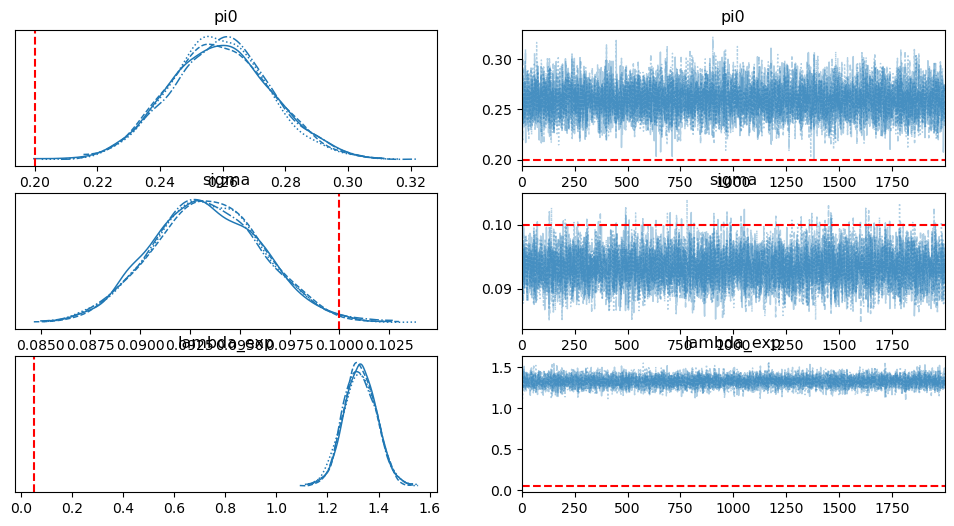

In [50]:
trace_plot = az.plot_trace(trace, var_names=["pi0", "sigma", "lambda_exp"])
for ax, true_value in zip(trace_plot[:,0].ravel(), [true_pi0, true_sigma, true_lambda]):
    ax.axvline(true_value, color="red", linestyle="--", label=f"True value: {true_value}")
for ax, true_value in zip(trace_plot[:,1].ravel(), [true_pi0, true_sigma, true_lambda]):
    ax.axhline(true_value, color="red", linestyle="--", label=f"True value: {true_value}")

#### Model QA
Plot on the left: A good model converged to the same posterior across runs

Plot on the right: A good model show a homogeneous trace. If you see that in the beginning the trace did not converge to a stable value, you need to not use the samples in the beginning for inference

<Axes: >

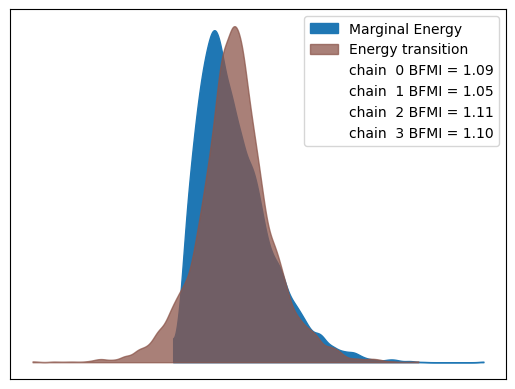

In [51]:
az.plot_energy(trace)

#### Model QA
If NUTS algorithm was able to adequately explore the posterior distribution, both displayed distributions should overlap

array([[<Axes: title={'center': 'pi0\n0'}>,
        <Axes: title={'center': 'pi0\n1'}>,
        <Axes: title={'center': 'pi0\n2'}>],
       [<Axes: title={'center': 'pi0\n3'}>,
        <Axes: title={'center': 'sigma\n0'}>,
        <Axes: title={'center': 'sigma\n1'}>],
       [<Axes: title={'center': 'sigma\n2'}>,
        <Axes: title={'center': 'sigma\n3'}>,
        <Axes: title={'center': 'lambda_exp\n0'}>],
       [<Axes: title={'center': 'lambda_exp\n1'}>,
        <Axes: title={'center': 'lambda_exp\n2'}>,
        <Axes: title={'center': 'lambda_exp\n3'}>]], dtype=object)

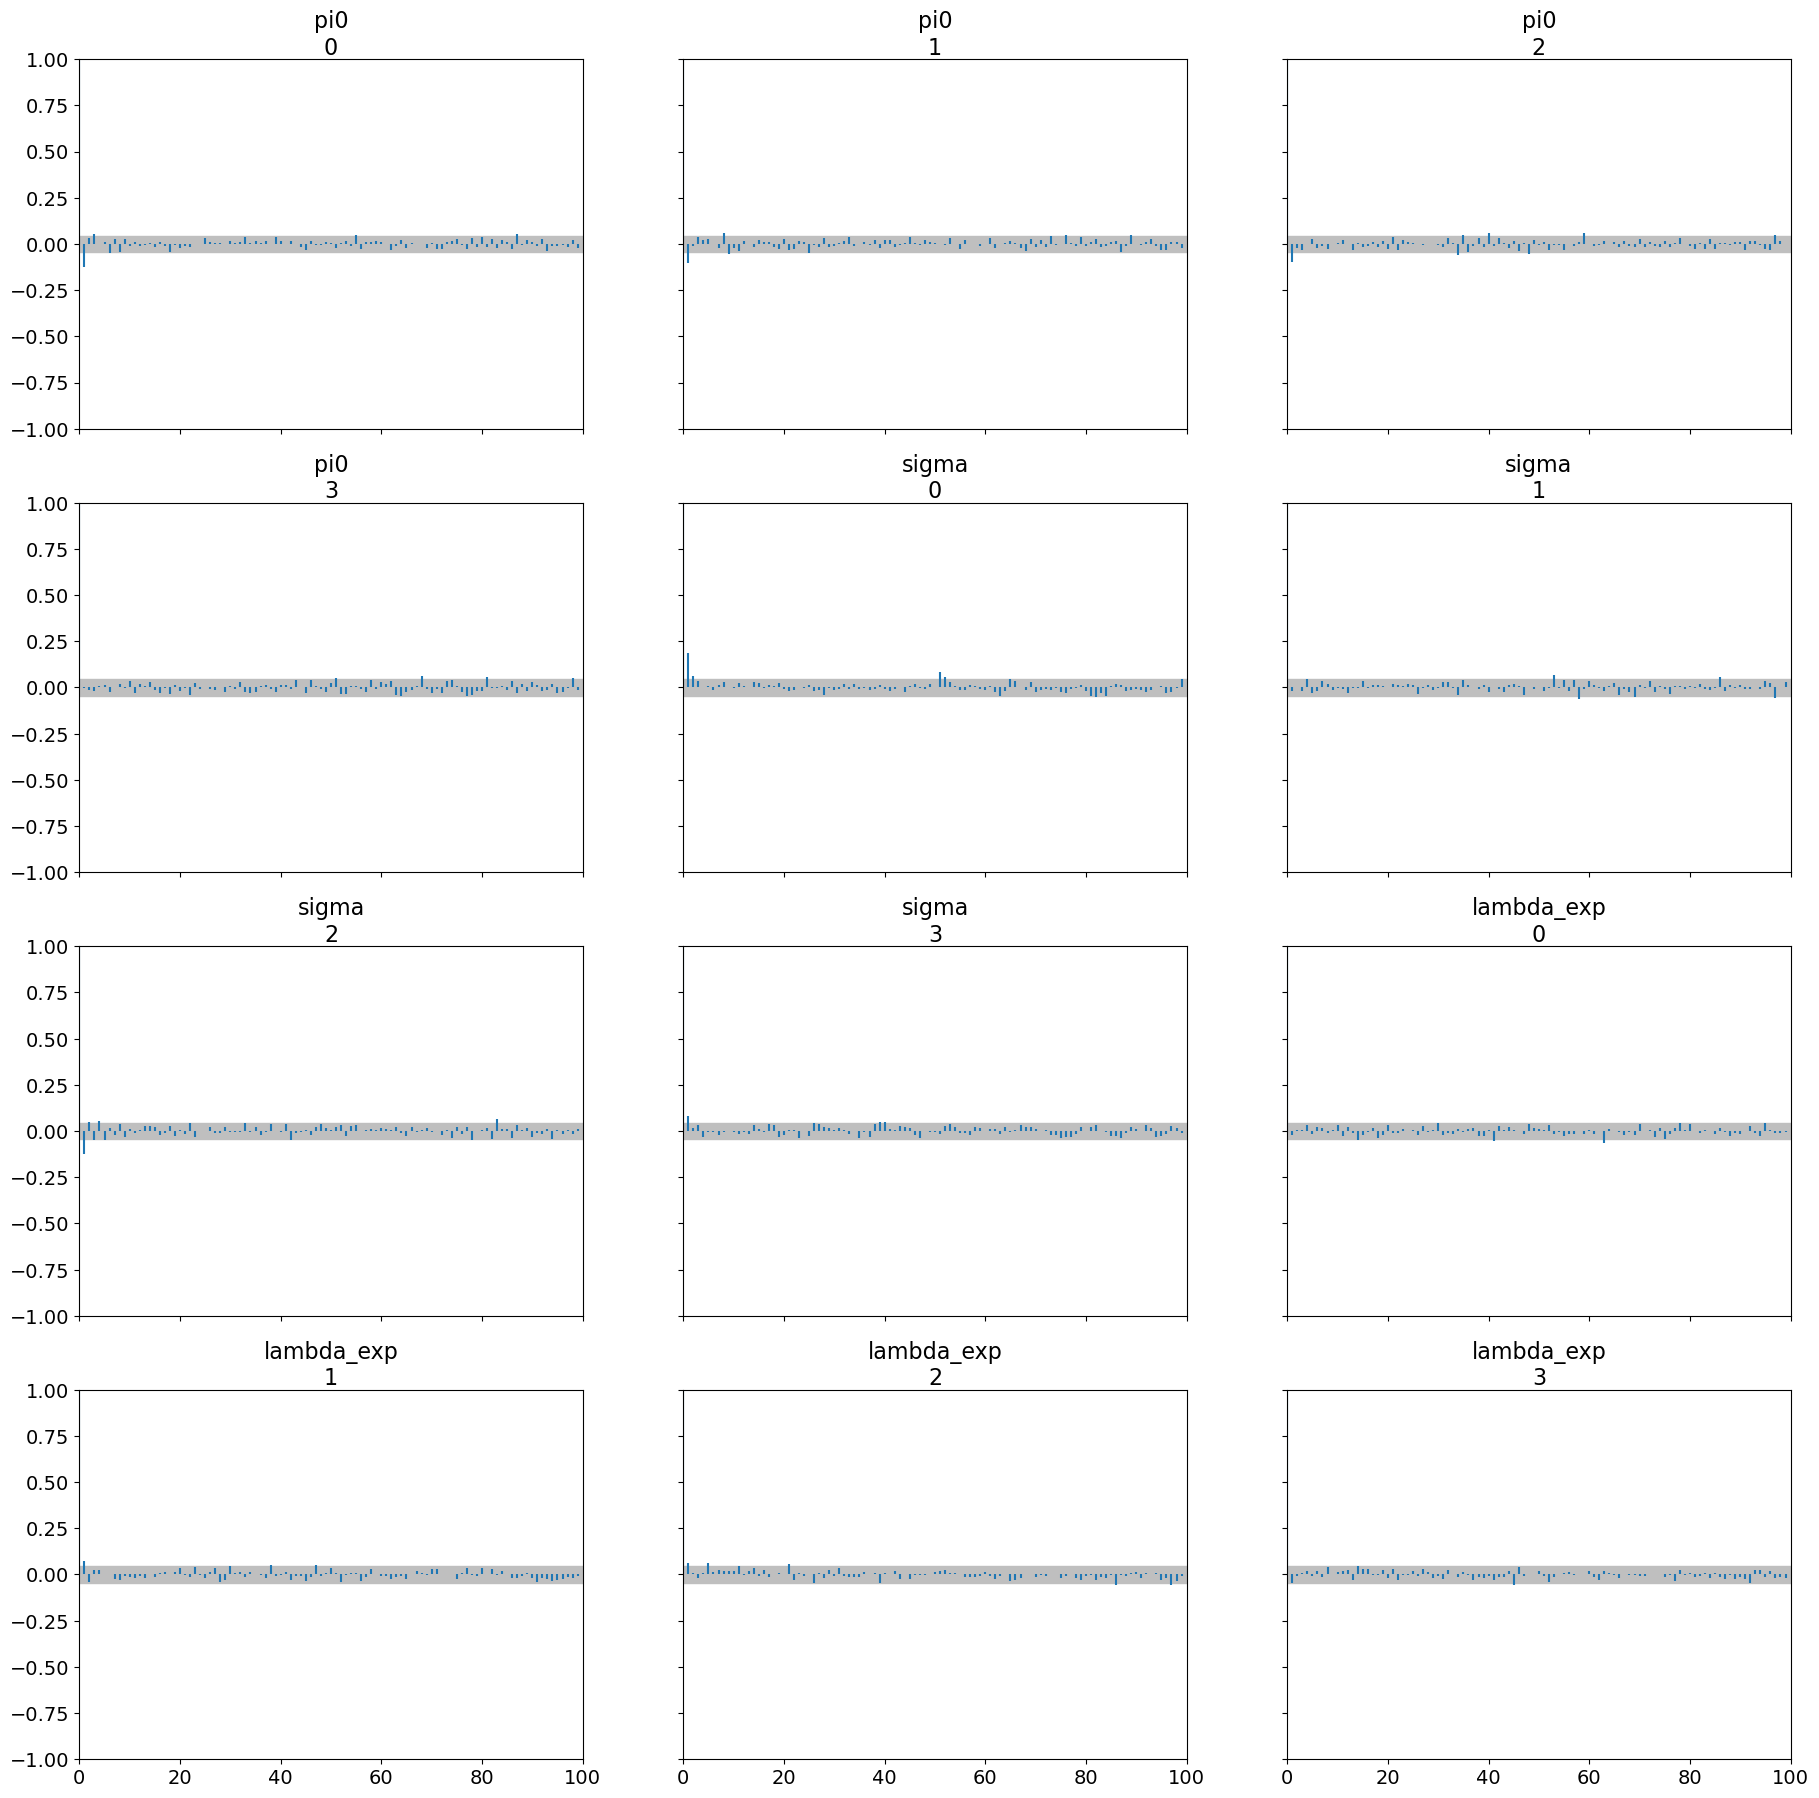

In [52]:
az.plot_autocorr(trace, var_names=["pi0", "sigma", "lambda_exp"])

#### Model QA
The trace should not show autocorrelation (i.e. peaks should be scattered around zero, alertnating between negative and positive value and small). A decaying distribution of tall peaks indicates autocorrelation in the trace. Many downstream algorithms require samples to be *independent*, hence the importance of checking that no autocorrelation is present in the trace. If it is, you can use thinning to reduce autocorrelation.

## Model fitted to our simulated SC matrices

(36, 5, 5)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [pi0, sigma, lambda_exp]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 3 seconds.
There were 1153 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


array([[<Axes: title={'center': 'pi0\n0'}>,
        <Axes: title={'center': 'pi0\n1'}>,
        <Axes: title={'center': 'pi0\n2'}>],
       [<Axes: title={'center': 'pi0\n3'}>,
        <Axes: title={'center': 'sigma\n0'}>,
        <Axes: title={'center': 'sigma\n1'}>],
       [<Axes: title={'center': 'sigma\n2'}>,
        <Axes: title={'center': 'sigma\n3'}>,
        <Axes: title={'center': 'lambda_exp\n0'}>],
       [<Axes: title={'center': 'lambda_exp\n1'}>,
        <Axes: title={'center': 'lambda_exp\n2'}>,
        <Axes: title={'center': 'lambda_exp\n3'}>]], dtype=object)

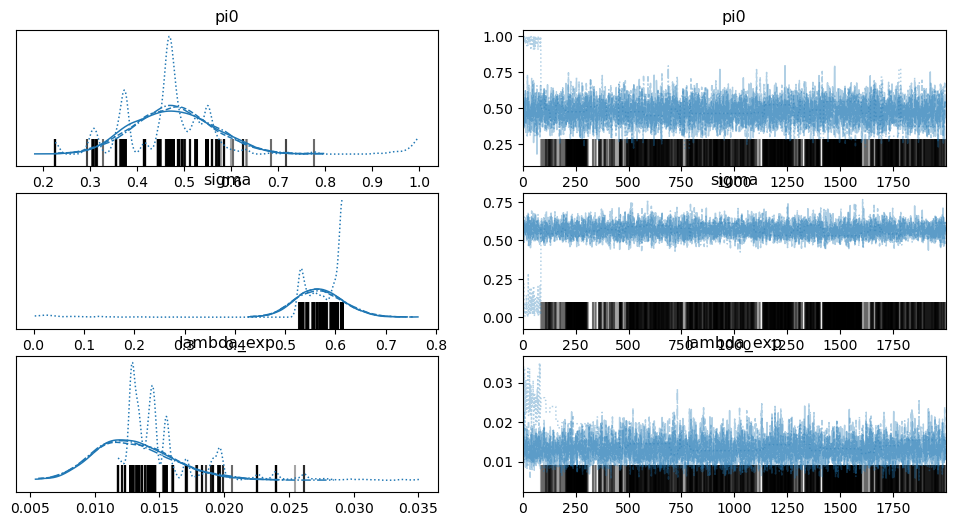

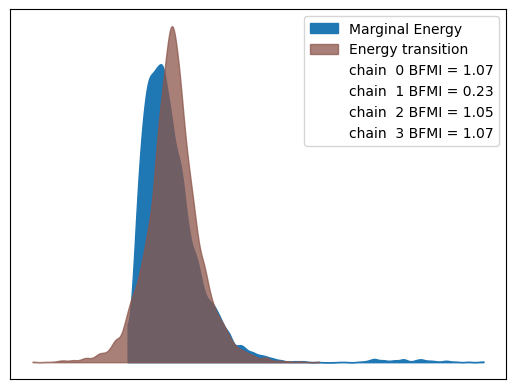

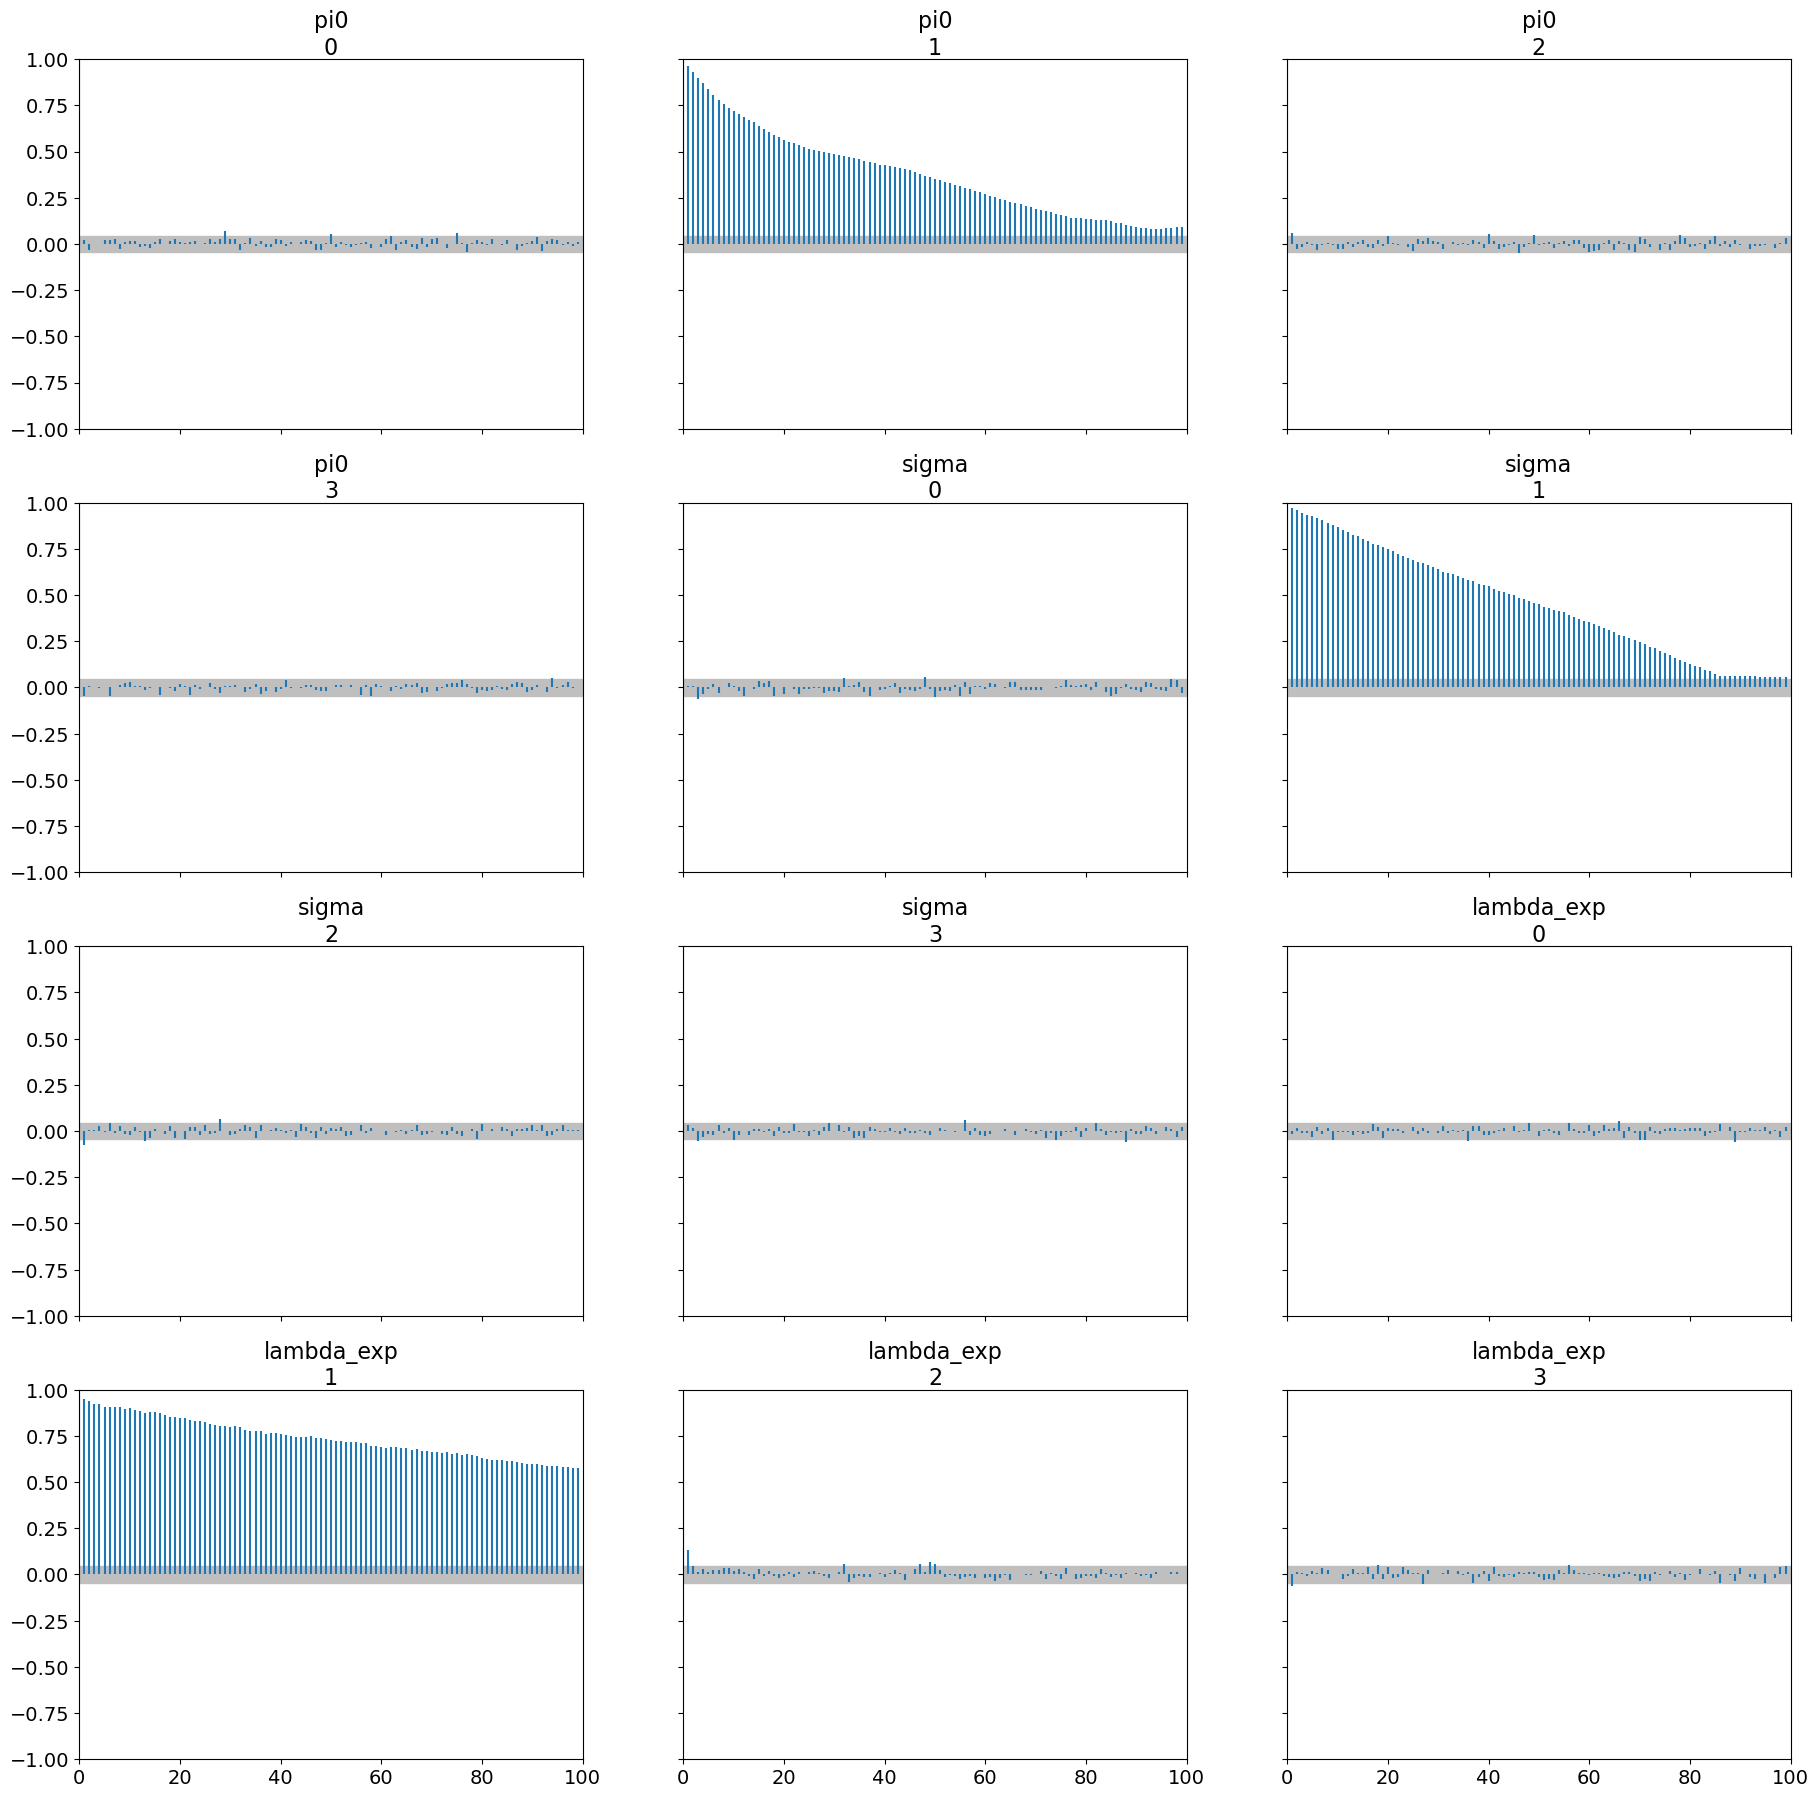

In [53]:
print(SC_matrices.shape)
with pm.Model() as model:

    # Prior for sparsity
    pi0 = pm.Beta('pi0', alpha=1, beta=1)

    # Prior for sigma (spread of real connections)
    sigma = pm.HalfNormal('sigma', sigma=0.1)

    # Fixed mean for real connections
    #mu = pm.Normal('mu', mu=true_mu, sigma=0.5)
    mu = true_mu

    # Prior for lambda (rate of Exponential for small spurious connections)
    lambda_exp = pm.Gamma('lambda_exp', alpha=2, beta=3) 

    # Component 1: Exponential distribution for "no connection"
    density_small = pm.Exponential.dist(lam=lambda_exp)

    # Component 2: Truncated Normal distribution for "existing connection"
    density_existing = pm.TruncatedNormal.dist(mu=mu, sigma=sigma, lower=0)

    # Mixture of the two
    density = pm.Mixture(
        'density',
        w=[pi0, 1 - pi0],
        comp_dists=[density_small, density_existing],
        observed=SC_matrices[:,0,0]
    )

    trace = pm.sample(2000, tune=1000, target_accept=0.9)

# Summarize
az.summary(trace, var_names=["pi0", "sigma", "lambda_exp"])
az.plot_trace(trace, var_names=["pi0", "sigma", "lambda_exp"])
az.plot_energy(trace)
az.plot_autocorr(trace, var_names=["pi0", "sigma", "lambda_exp"])